In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('../data/Wildlife_Export_2023_2025.csv', encoding='latin-1')

C:\Users\Dheick\AppData\Local\Temp\ipykernel_37092\3854085828.py:1: DtypeWarning: Columns (0: AIRPORT_LATITUDE, 1: AIRPORT_LONGITUDE, 2: BIRD_BAND_NUMBER, 3: LUPDATE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/Wildlife_Export_2023_2025.csv', encoding='latin-1')


In [4]:
df.columns = df.columns.str.strip()

In [6]:
df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'])

### Cleaning the Data
* After my initial observations of the data - I have decided to eliminate the following columns:
* <u>REDUNDANT DATE FIELDS</u>
    * `INCIDENT_MONTH`
    * `INCIDENT_YEAR`
* <u>ADMINISTRATIVE COLUMNS</u>
    * `INDX_NR` - Database index.
    * `LUPDATE` - last update timestamp
    * `TRANSFER` - Transfer tag
    * `IMAGE` - Boolean for whether a phot was taken, not useful.
    * `REPORTER_NAME` - Mostly redacted
    * `REPORTER_TITLE` - Mostly redacted
    * `PERSON` - Redacted
    * `FLT`
    * `REG`
* <u>MISSING DATA</u>
    * `BIRD_BAND_NUMBER`
    * `ENG_4_POS`
    * `COST_REPAIRS`
    * `EFFECT_OTHER`
    * `ENG_3_POS`
    * `COST_OTHER_INFL_ADJ`
    * `COST_OTHER`
    * `ENROUTE_STATE`
    * `AOS`
    * `OTHER_SPECIFY`
    * `LOCATION`
    * `INJESTED_OTHER`
* <u>AIRCRAFT MAKE/MODEL CODES MADE REDUNDANT BY `AIRCRAFT`</u>
    * `AMA`
    * `AMO`
    * `EMA`
    * `EMO`
* <u>Dropping Rows Where `AC_MASS` Is Missing</u>
    * For this analysis, I'm only including incidents where a strike was directly observed — not cases inferred from finding a carcass near an airport. Since `AC_MASS` appears to be missing in those unobserved cases, I'll drop any rows where this field is null.

In [5]:
df_AC = df.drop(['INCIDENT_MONTH','INCIDENT_YEAR','INDX_NR','LUPDATE','TRANSFER','IMAGE',
                    'REPORTER_NAME','REPORTER_TITLE','PERSON','FLT','REG','BIRD_BAND_NUMBER',
                    'ENG_4_POS','COST_REPAIRS','EFFECT_OTHER','ENG_3_POS','COST_OTHER_INFL_ADJ',
                    'COST_OTHER','ENROUTE_STATE','AOS','OTHER_SPECIFY','LOCATION','INGESTED_OTHER',
                    'AMA','AMO','EMA','EMO','NR_INJURIES', 'NR_FATALITIES'], axis=1) \
             .dropna(subset=['AC_MASS'])

### Graphing Effect on Aircraft Depending on Mass
In this chart I am comparing the mass of aircraft who have a wildlife strike and the effect that this strike has. I have added a verticle line which is showing the aveage mass of all aircrafts involved in an strike.


In [8]:
effect_mass = df_AC.groupby('EFFECT')['AC_MASS'].mean().sort_values()
print(effect_mass)

EFFECT
Engine Shutdown                                  1.636364
None, Precautionary Landing                      2.000000
Precautionary Landing                            2.132394
Engine Shutdown, Other                           2.333333
Aborted Take-off                                 2.410891
Precautionary Landing, Engine Shutdown           2.500000
Aborted Take-off, Engine Shutdown                2.666667
Other                                            2.679577
None, Other                                      3.000000
Aborted Take-off, Other                          3.200000
Precautionary Landing, Other                     3.256410
Precautionary Landing, Engine Shutdown, Other    3.555556
None                                             3.737940
Name: AC_MASS, dtype: float64


In [12]:
df_AC['AC_MASS'].mean()

np.float64(3.6722577038040556)

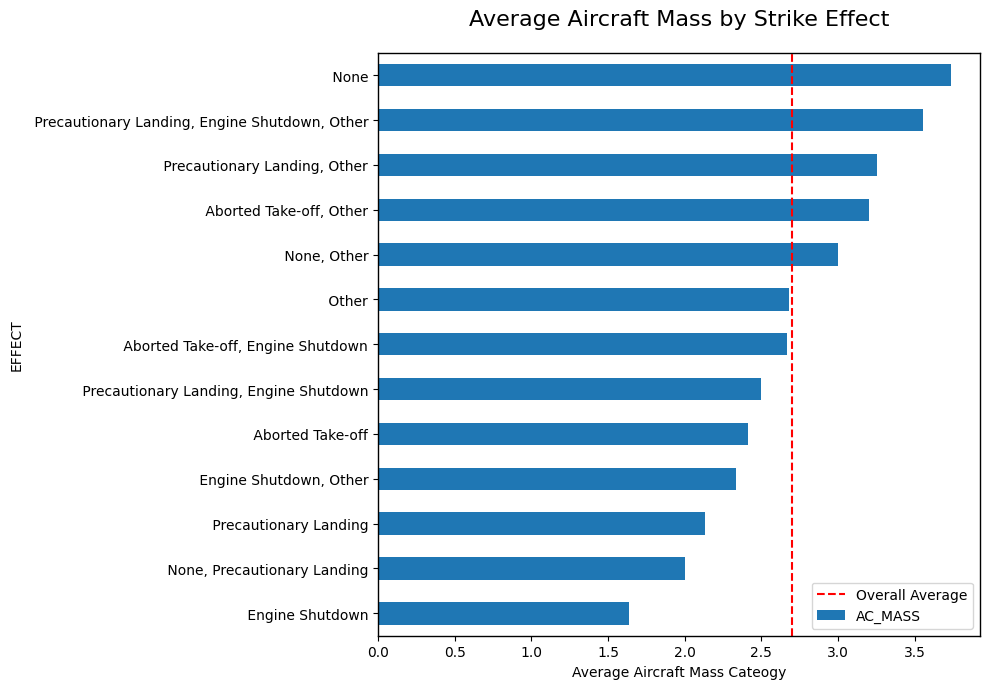

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
effect_mass.plot(kind='barh', ax=ax)

plt.xlabel("Average Aircraft Mass Cateogy")
plt.ylabel("EFFECT")
plt.title("Average Aircraft Mass by Strike Effect", fontsize=16, pad=20)
plt.axvline(x=effect_mass.mean(), color='red', linestyle="--", label='Overall Average')
ax.legend()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_alpha(1)

plt.tight_layout()
plt.show()


In [39]:
df_AC['PHASE_OF_FLIGHT'].value_counts()

PHASE_OF_FLIGHT
Approach        15691
Landing Roll     6543
Take-off Run     5317
Climb            4254
Departure        1422
En Route         1047
Descent           613
Arrival           417
Local             289
Taxi              152
Unknown             9
Parked              5
Name: count, dtype: int64

<Axes: >

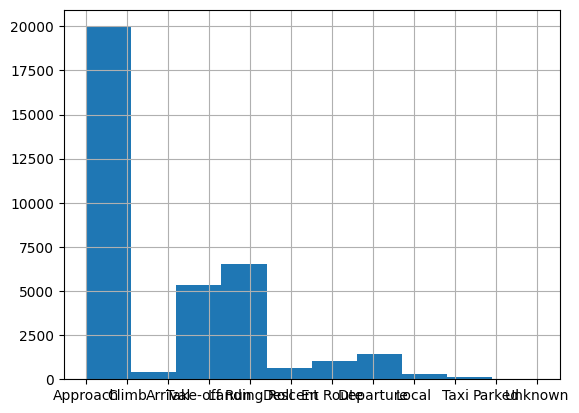

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(
    df_AC['PHASE_OF_FLIGHT'],
    bins=20,
    color="#1de144",
    edgecolor="white"
)

plt.xlabel("Average Stream Duration (Minutes)")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Average Stream Duration", fontsize=16, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()